In [1]:
# Data Preprocessing: Kalimati Tarkari Dataset
# Final Assessment - Crop Price Prediction

import pandas as pd
import numpy as np

# Load the raw dataset
df = pd.read_csv('../data/raw/Kalimati_Tarkari_Dataset.csv', low_memory=False)
print("Original shape:", df.shape)

# ---------- Step 1: Fix mixed date formats ----------
# The Date column has two formats: M/D/YYYY (older rows) and YYYY-MM-DD (newer rows).
# We try the first format, and for rows that fail, we try the second format.
def parse_date(date_str):
    for fmt in ('%m/%d/%Y', '%Y-%m-%d'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT  # if neither format works, mark as missing

df['Date'] = df['Date'].apply(parse_date)
print("Rows with unparseable dates:", df['Date'].isnull().sum())

# ---------- Step 2: Clean price columns (remove "Rs" text) ----------
def clean_price(value):
    if isinstance(value, str):
        value = value.replace('Rs', '').replace(',', '').strip()
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

for col in ['Minimum', 'Maximum', 'Average']:
    df[col] = df[col].apply(clean_price)

# ---------- Step 3: Drop rows with missing critical values ----------
df = df.dropna(subset=['Date', 'Minimum', 'Maximum', 'Average'])
print("Shape after cleaning:", df.shape)

# ---------- Step 4: Filter to our 3 target crops ----------
target_crops = ['Tomato', 'Potato', 'Onion']
df_filtered = df[df['Commodity'].str.contains('|'.join(target_crops), case=False, na=False)].copy()
print("\nFiltered shape:", df_filtered.shape)
print("\nCommodities included:")
print(df_filtered['Commodity'].unique())

# ---------- Step 5: Check for duplicates ----------
duplicates = df_filtered.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
df_filtered = df_filtered.drop_duplicates()

# ---------- Step 6: Save the cleaned dataset ----------
df_filtered.to_csv('../data/processed/kalimati_cleaned.csv', index=False)
print("\nSaved cleaned dataset as 'kalimati_cleaned.csv'")
print("Final shape:", df_filtered.shape)
print("\nFirst 5 rows:")
print(df_filtered.head())

Original shape: (280862, 6)
Rows with unparseable dates: 0
Shape after cleaning: (280862, 6)

Filtered shape: (28197, 6)

Commodities included:
<ArrowStringArray>
[  'Tomato Big(Nepali)',  'Tomato Small(Local)',           'Potato Red',
         'Potato White',   'Onion Dry (Indian)',          'Onion Green',
         'Sweet Potato', 'Tomato Small(Tunnel)',   'Potato Red(Indian)',
     'Potato Red(Mude)',   'Tomato Big(Indian)', 'Tomato Small(Indian)',
  'Tomato Small(Terai)',  'Onion Dry (Chinese)',          'Tree Tomato']
Length: 15, dtype: str

Duplicate rows: 0

Saved cleaned dataset as 'kalimati_cleaned.csv'
Final shape: (28197, 6)

First 5 rows:
             Commodity       Date Unit  Minimum  Maximum  Average
0   Tomato Big(Nepali) 2013-06-16   Kg     35.0     40.0     37.5
1  Tomato Small(Local) 2013-06-16   Kg     26.0     32.0     29.0
2           Potato Red 2013-06-16   Kg     20.0     21.0     20.5
3         Potato White 2013-06-16   Kg     15.0     16.0     15.5
4   Onion Dr

In [2]:
# ---------- Feature Engineering ----------
# Convert date into useful numeric features, and encode the commodity name

# Extract time-based features from Date
df_filtered['Year'] = df_filtered['Date'].dt.year
df_filtered['Month'] = df_filtered['Date'].dt.month
df_filtered['DayOfWeek'] = df_filtered['Date'].dt.dayofweek  # 0=Monday, 6=Sunday

# Create a "Season" feature (Nepal's agricultural seasons)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df_filtered['Season'] = df_filtered['Month'].apply(get_season)

# Simplify 15 commodity variants into 3 main crop categories
def simplify_commodity(name):
    if 'Tomato' in name:
        return 'Tomato'
    elif 'Potato' in name:
        return 'Potato'
    elif 'Onion' in name:
        return 'Onion'
    return name

df_filtered['Crop'] = df_filtered['Commodity'].apply(simplify_commodity)

# Sort by Crop and Date (required before creating lag features)
df_filtered = df_filtered.sort_values(['Crop', 'Date']).reset_index(drop=True)

# Create lag features: previous day's and previous week's price
# groupby('Crop') ensures lag values don't leak across different crops
df_filtered['Price_Lag1'] = df_filtered.groupby('Crop')['Average'].shift(1)
df_filtered['Price_Lag7'] = df_filtered.groupby('Crop')['Average'].shift(7)

# Drop rows where lag features couldn't be created (first few rows per crop)
df_filtered = df_filtered.dropna(subset=['Price_Lag1', 'Price_Lag7'])

print("Shape after feature engineering:", df_filtered.shape)
print("\nNew columns:", df_filtered.columns.tolist())
print("\nSample rows:")
print(df_filtered[['Crop', 'Date', 'Season', 'Average', 'Price_Lag1', 'Price_Lag7']].head(10))

# Save the feature-engineered dataset
df_filtered.to_csv('../data/processed/kalimati_features.csv', index=False)
print("\nSaved as 'kalimati_features.csv'")

Shape after feature engineering: (28176, 13)

New columns: ['Commodity', 'Date', 'Unit', 'Minimum', 'Maximum', 'Average', 'Year', 'Month', 'DayOfWeek', 'Season', 'Crop', 'Price_Lag1', 'Price_Lag7']

Sample rows:
     Crop       Date   Season  Average  Price_Lag1  Price_Lag7
7   Onion 2013-06-19  Monsoon     42.5        34.5        29.0
8   Onion 2013-06-20  Monsoon     35.5        42.5        42.5
9   Onion 2013-06-20  Monsoon     37.5        35.5        29.5
10  Onion 2013-06-21  Monsoon     34.5        37.5        42.5
11  Onion 2013-06-21  Monsoon     37.5        34.5        34.0
12  Onion 2013-06-25  Monsoon     34.0        37.5        37.5
13  Onion 2013-06-25  Monsoon     42.5        34.0        34.5
14  Onion 2013-06-26  Monsoon     34.0        42.5        42.5
15  Onion 2013-06-26  Monsoon     37.5        34.0        35.5
16  Onion 2013-06-27  Monsoon     36.0        37.5        37.5

Saved as 'kalimati_features.csv'


=== Summary Statistics (Average Price by Crop) ===
          count       mean        std   min   25%   50%   75%     max
Crop                                                                 
Onion    7280.0  64.070706  41.631310  15.0  35.0  52.5  82.5  325.00
Potato   9965.0  38.157058  16.706263  11.0  26.5  34.0  46.5  115.00
Tomato  10931.0  46.728406  22.177545   5.8  31.5  45.0  57.5  173.33


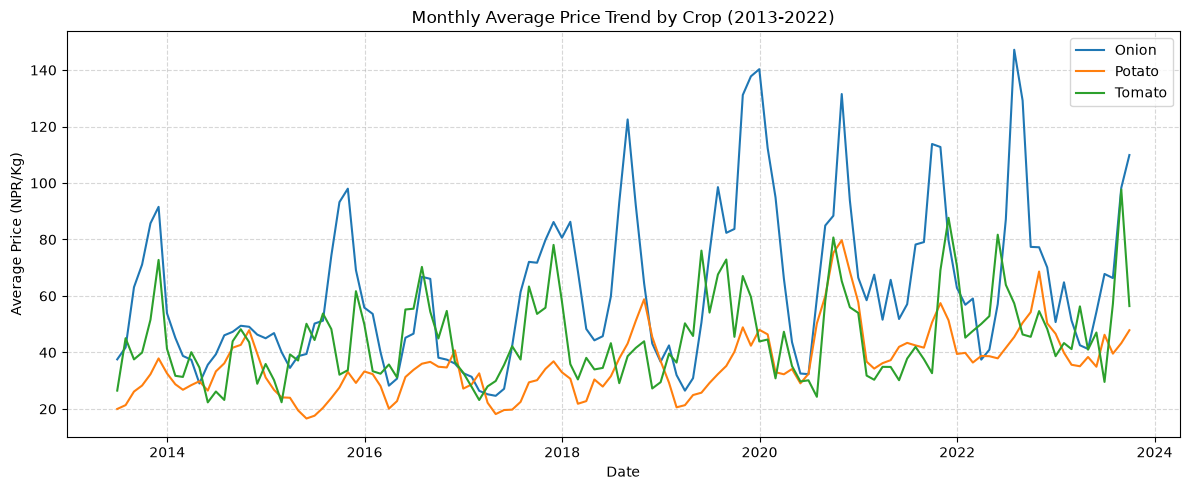

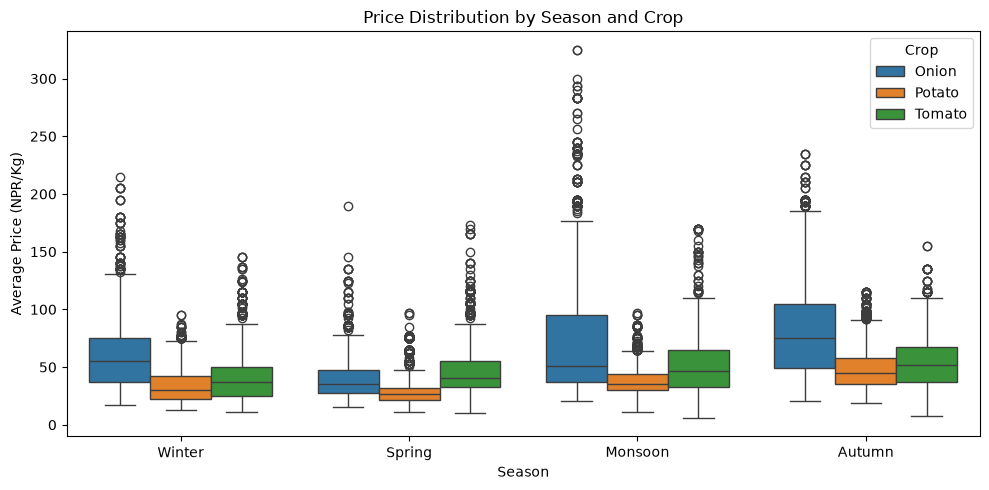

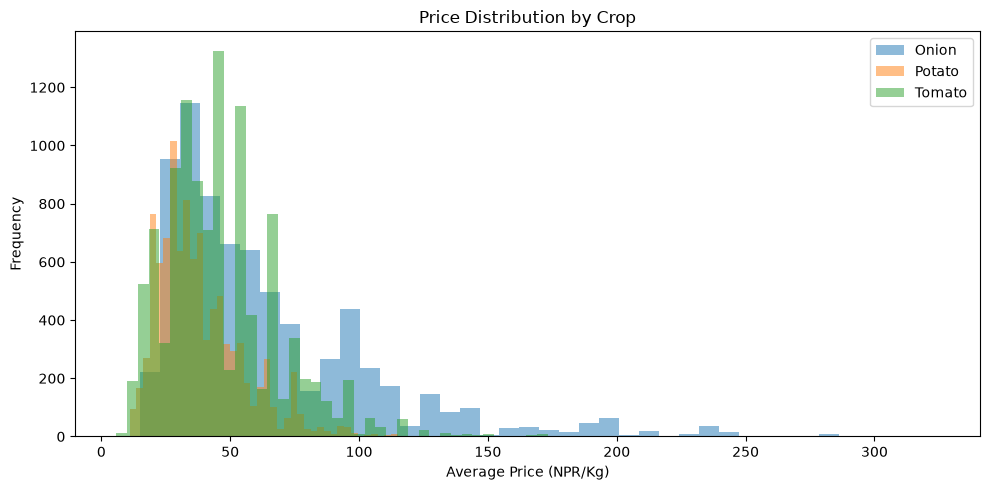

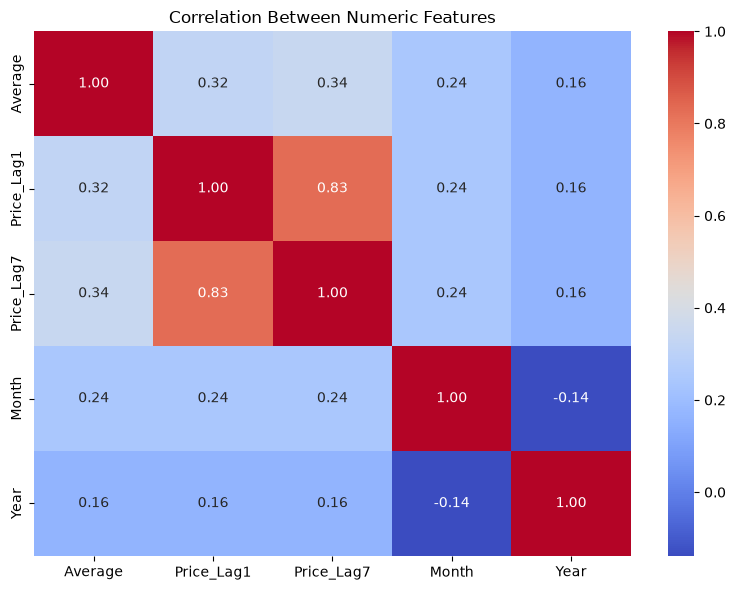

In [3]:
# ---------- Exploratory Data Analysis (EDA) ----------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1. Summary statistics ----------
print("=== Summary Statistics (Average Price by Crop) ===")
print(df_filtered.groupby('Crop')['Average'].describe())

# ---------- 2. Price trend over time (per crop) ----------
plt.figure(figsize=(12, 5))
for crop in df_filtered['Crop'].unique():
    crop_data = df_filtered[df_filtered['Crop'] == crop]
    # Resample to monthly average to make the trend line readable
    monthly = crop_data.set_index('Date')['Average'].resample('ME').mean()
    plt.plot(monthly.index, monthly.values, label=crop)

plt.title('Monthly Average Price Trend by Crop (2013-2022)')
plt.xlabel('Date')
plt.ylabel('Average Price (NPR/Kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../visuals/e1_price_trend.png', dpi=150)
plt.show()

# ---------- 3. Seasonal price pattern ----------
plt.figure(figsize=(10, 5))
season_order = ['Winter', 'Spring', 'Monsoon', 'Autumn']
sns.boxplot(data=df_filtered, x='Season', y='Average', hue='Crop', order=season_order)
plt.title('Price Distribution by Season and Crop')
plt.xlabel('Season')
plt.ylabel('Average Price (NPR/Kg)')
plt.tight_layout()
plt.savefig('../visuals/e2_seasonal_boxplot.png', dpi=150)
plt.show()

# ---------- 4. Price distribution (histogram) ----------
plt.figure(figsize=(10, 5))
for crop in df_filtered['Crop'].unique():
    crop_data = df_filtered[df_filtered['Crop'] == crop]
    plt.hist(crop_data['Average'], bins=40, alpha=0.5, label=crop)

plt.title('Price Distribution by Crop')
plt.xlabel('Average Price (NPR/Kg)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/e3_price_distribution.png', dpi=150)
plt.show()

# ---------- 5. Correlation heatmap (numeric features) ----------
plt.figure(figsize=(8, 6))
numeric_cols = ['Average', 'Price_Lag1', 'Price_Lag7', 'Month', 'Year']
corr_matrix = df_filtered[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.savefig('../visuals/e4_correlation_heatmap.png', dpi=150)
plt.show()

In [4]:
# Verify: check lag correlation WITHIN each crop separately
print("=== Correlation between Average and Price_Lag1, per crop ===")
for crop in df_filtered['Crop'].unique():
    crop_data = df_filtered[df_filtered['Crop'] == crop]
    corr = crop_data[['Average', 'Price_Lag1']].corr().iloc[0, 1]
    print(f"{crop}: {corr:.3f}")

=== Correlation between Average and Price_Lag1, per crop ===
Onion: 0.058
Potato: 0.375
Tomato: 0.553


In [5]:
# ---------- Fix: Aggregate to one row per (Crop, Date) before creating lag features ----------
# This prevents lag features from jumping across different sub-varieties on the same date

df_daily = df_filtered.groupby(['Crop', 'Date'])['Average'].mean().reset_index()
df_daily = df_daily.sort_values(['Crop', 'Date']).reset_index(drop=True)

# Recreate lag features on this clean daily series
df_daily['Price_Lag1'] = df_daily.groupby('Crop')['Average'].shift(1)
df_daily['Price_Lag7'] = df_daily.groupby('Crop')['Average'].shift(7)

# Re-add Month, Year, Season from Date
df_daily['Year'] = df_daily['Date'].dt.year
df_daily['Month'] = df_daily['Date'].dt.month
df_daily['Season'] = df_daily['Month'].apply(get_season)

df_daily = df_daily.dropna(subset=['Price_Lag1', 'Price_Lag7'])

print("Shape after proper daily aggregation:", df_daily.shape)

# Verify correlation again
print("\n=== Corrected Correlation between Average and Price_Lag1, per crop ===")
for crop in df_daily['Crop'].unique():
    crop_data = df_daily[df_daily['Crop'] == crop]
    corr = crop_data[['Average', 'Price_Lag1']].corr().iloc[0, 1]
    print(f"{crop}: {corr:.3f}")

# Save this as our final modeling dataset
df_daily.to_csv('../data/processed/kalimati_features.csv', index=False)
print("\nSaved corrected features as 'kalimati_features.csv'")

Shape after proper daily aggregation: (10814, 8)

=== Corrected Correlation between Average and Price_Lag1, per crop ===
Onion: 0.965
Potato: 0.976
Tomato: 0.958

Saved corrected features as 'kalimati_features.csv'


In [7]:
# ---------- Step 5: Model Implementation ----------
# Train and compare 4 regression algorithms to predict crop price

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load the corrected, feature-engineered dataset
df_daily = pd.read_csv('../data/processed/kalimati_features.csv')
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

# ---------- Prepare features (X) and target (y) ----------
# Target: what we want to predict
y = df_daily['Average']

# Features: what the model uses to make the prediction
# One-hot encode 'Crop' and 'Season' (turn text categories into 0/1 columns,
# since ML models need numbers, not text)
X = pd.get_dummies(df_daily[['Crop', 'Season', 'Month', 'Year',
                              'Price_Lag1', 'Price_Lag7']],
                    columns=['Crop', 'Season'], drop_first=True)

print("Feature columns:", X.columns.tolist())
print("Feature matrix shape:", X.shape)

# ---------- Time-based train-test split ----------
# We do NOT shuffle randomly, because this is time-series data:
# training on future prices to predict the past would be unrealistic (data leakage).
# Instead we sort by date and use the earliest 80% for training, latest 20% for testing.
df_daily_sorted = df_daily.sort_values('Date')
split_index = int(len(df_daily_sorted) * 0.8)

train_idx = df_daily_sorted.index[:split_index]
test_idx = df_daily_sorted.index[split_index:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# ---------- Feature scaling ----------
# Some models (SVR) are sensitive to feature scale; others (Decision Tree) are not.
# We create a scaled version for models that need it.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn scale from training data only
X_test_scaled = scaler.transform(X_test)          # apply the same scale to test data

# ---------- Define the 4 models ----------
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=8, random_state=42),
    'SVR': SVR(kernel='rbf', C=10, epsilon=0.5)
}

# ---------- Train each model and evaluate ----------
results = []

for name, model in models.items():
    # SVR and Linear/Ridge models benefit from scaled features;
    # Decision Tree does not need scaling (tree splits don't care about feature scale)
    if name == 'Decision Tree Regressor':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Compute evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 3),
        'MSE': round(mse, 3),
        'RMSE': round(rmse, 3),
        'R2': round(r2, 4)
    })

# ---------- Display results as a comparison table ----------
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

# Save results table for the report
results_df.to_csv('../report/model_comparison_results.csv', index=False)
print("\nSaved results table to report/model_comparison_results.csv")

Feature columns: ['Month', 'Year', 'Price_Lag1', 'Price_Lag7', 'Crop_Potato', 'Crop_Tomato', 'Season_Monsoon', 'Season_Spring', 'Season_Winter']
Feature matrix shape: (10814, 9)

Training samples: 8651
Testing samples: 2163

=== Model Comparison ===
                  Model   MAE    MSE  RMSE     R2
      Linear Regression 3.965 51.547 7.180 0.9186
       Ridge Regression 3.966 51.543 7.179 0.9186
Decision Tree Regressor 4.496 65.280 8.080 0.8969
                    SVR 4.875 83.179 9.120 0.8686

Saved results table to report/model_comparison_results.csv


=== Effect of Feature Scaling on Model Performance ===
                  Model  R2 (No Scaling)  R2 (Scaled)  R2 Difference  MAE (No Scaling)  MAE (Scaled)
      Linear Regression           0.9186       0.9186         0.0000             3.965         3.965
       Ridge Regression           0.9186       0.9186         0.0000             3.965         3.966
Decision Tree Regressor           0.8969       0.8969        -0.0000             4.496         4.497
                    SVR           0.8658       0.8686         0.0028             5.595         4.875

Saved to report/scaling_comparison_results.csv


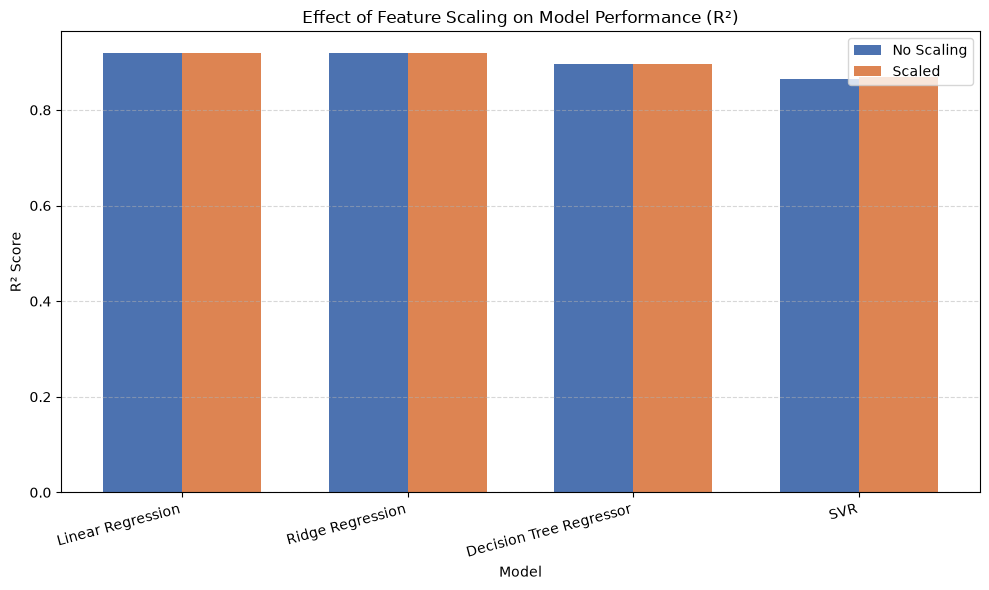

In [8]:
# ---------- Step 6: Comparative Study — Effect of Feature Scaling ----------
# Compare model performance WITH scaling vs WITHOUT scaling

scaling_results = []

for name, model_class in [
    ('Linear Regression', LinearRegression),
    ('Ridge Regression', lambda: Ridge(alpha=1.0)),
    ('Decision Tree Regressor', lambda: DecisionTreeRegressor(max_depth=8, random_state=42)),
    ('SVR', lambda: SVR(kernel='rbf', C=10, epsilon=0.5))
]:
    # ---------- WITHOUT scaling ----------
    model_unscaled = model_class() if callable(model_class) else model_class
    model_unscaled.fit(X_train, y_train)
    y_pred_unscaled = model_unscaled.predict(X_test)
    r2_unscaled = r2_score(y_test, y_pred_unscaled)
    mae_unscaled = mean_absolute_error(y_test, y_pred_unscaled)

    # ---------- WITH scaling ----------
    model_scaled = model_class() if callable(model_class) else model_class
    model_scaled.fit(X_train_scaled, y_train)
    y_pred_scaled = model_scaled.predict(X_test_scaled)
    r2_scaled = r2_score(y_test, y_pred_scaled)
    mae_scaled = mean_absolute_error(y_test, y_pred_scaled)

    scaling_results.append({
        'Model': name,
        'R2 (No Scaling)': round(r2_unscaled, 4),
        'R2 (Scaled)': round(r2_scaled, 4),
        'R2 Difference': round(r2_scaled - r2_unscaled, 4),
        'MAE (No Scaling)': round(mae_unscaled, 3),
        'MAE (Scaled)': round(mae_scaled, 3)
    })

scaling_df = pd.DataFrame(scaling_results)
print("=== Effect of Feature Scaling on Model Performance ===")
print(scaling_df.to_string(index=False))

# Save for the report
scaling_df.to_csv('../report/scaling_comparison_results.csv', index=False)
print("\nSaved to report/scaling_comparison_results.csv")

# ---------- Visualize the comparison ----------
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(scaling_df))
width = 0.35

ax.bar(x_pos - width/2, scaling_df['R2 (No Scaling)'], width, label='No Scaling', color='#4C72B0')
ax.bar(x_pos + width/2, scaling_df['R2 (Scaled)'], width, label='Scaled', color='#DD8452')

ax.set_xlabel('Model')
ax.set_ylabel('R² Score')
ax.set_title('Effect of Feature Scaling on Model Performance (R²)')
ax.set_xticks(x_pos)
ax.set_xticklabels(scaling_df['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../visuals/f1_scaling_comparison.png', dpi=150)
plt.show()

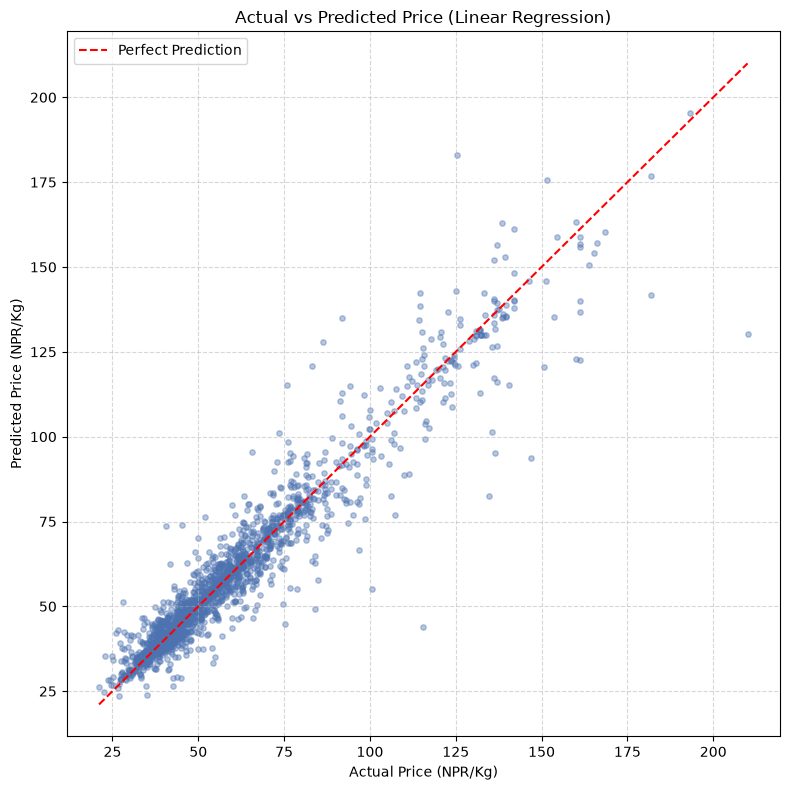

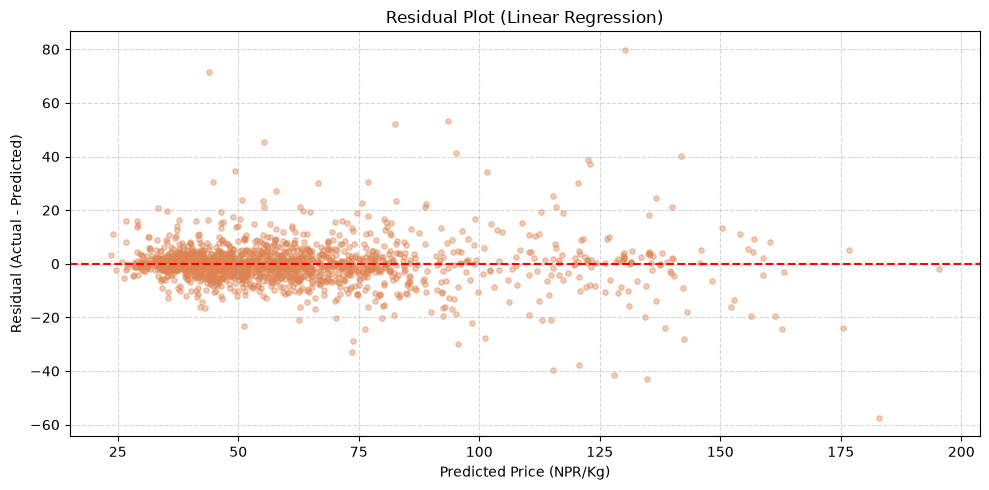

=== FINAL MODEL COMPARISON SUMMARY ===
                  Model   MAE    MSE  RMSE     R2
      Linear Regression 3.965 51.547 7.180 0.9186
       Ridge Regression 3.966 51.543 7.179 0.9186
Decision Tree Regressor 4.496 65.280 8.080 0.8969
                    SVR 4.875 83.179 9.120 0.8686

Best model: Linear Regression
Best R²: 0.9186
Best MAE: 3.965 NPR/Kg


In [9]:
# ---------- Step 7: Results & Discussion ----------
# Visualize actual vs predicted prices for the best model (Linear Regression)

best_model = LinearRegression()
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

# ---------- Plot 1: Actual vs Predicted scatter ----------
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.4, s=15, color='#4C72B0')
# Perfect prediction line (y = x): if points fall exactly on this line, prediction is perfect
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Price (NPR/Kg)')
plt.ylabel('Predicted Price (NPR/Kg)')
plt.title('Actual vs Predicted Price (Linear Regression)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../visuals/g1_actual_vs_predicted.png', dpi=150)
plt.show()

# ---------- Plot 2: Residuals (prediction errors) ----------
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_best, residuals, alpha=0.4, s=15, color='#DD8452')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (NPR/Kg)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot (Linear Regression)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../visuals/g2_residual_plot.png', dpi=150)
plt.show()

# ---------- Final summary table: combine model comparison + scaling results ----------
print("=== FINAL MODEL COMPARISON SUMMARY ===")
print(results_df.to_string(index=False))
print(f"\nBest model: {results_df.loc[results_df['R2'].idxmax(), 'Model']}")
print(f"Best R²: {results_df['R2'].max()}")
print(f"Best MAE: {results_df.loc[results_df['R2'].idxmax(), 'MAE']} NPR/Kg")